In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from tensorflow.keras import models, layers

2. LOAD DATASET

In [2]:
df = pd.read_csv("heart.csv")

print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


3. PREPROCESS DATA

In [3]:
X = df.drop('target', axis=1)
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

4. BUILD MODEL (Simple Neural Network)

In [4]:
model = models.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


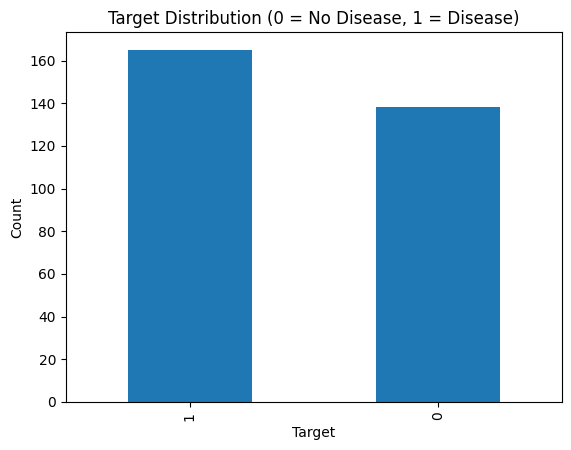

In [8]:
df['target'].value_counts().plot(kind='bar')
plt.title("Target Distribution (0 = No Disease, 1 = Disease)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

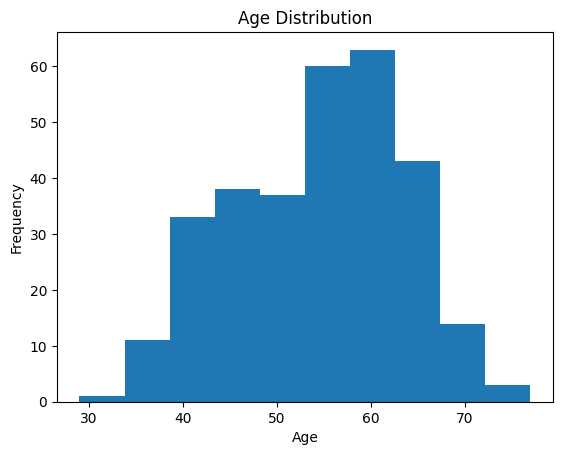

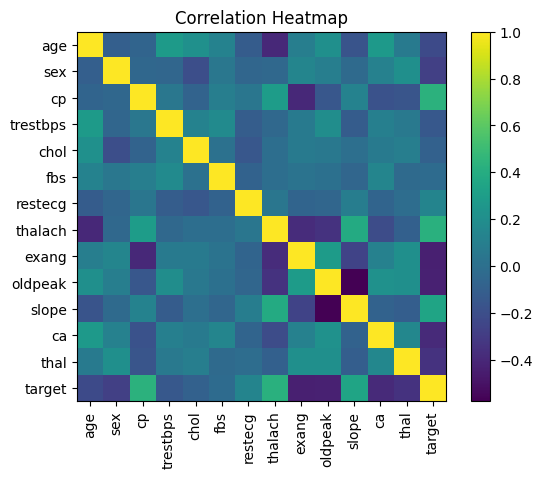

In [9]:
plt.hist(df['age'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()
corr = df.corr()

plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Heatmap")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()

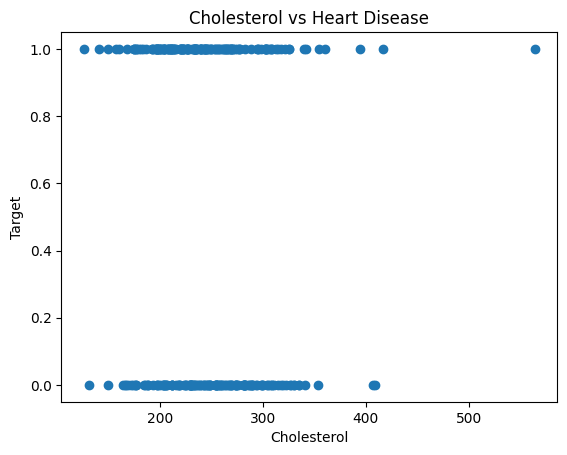

In [10]:
plt.scatter(df['chol'], df['target'])
plt.title("Cholesterol vs Heart Disease")
plt.xlabel("Cholesterol")
plt.ylabel("Target")
plt.show()

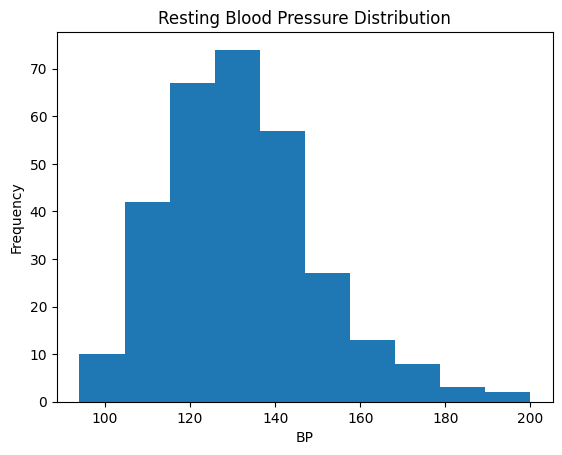

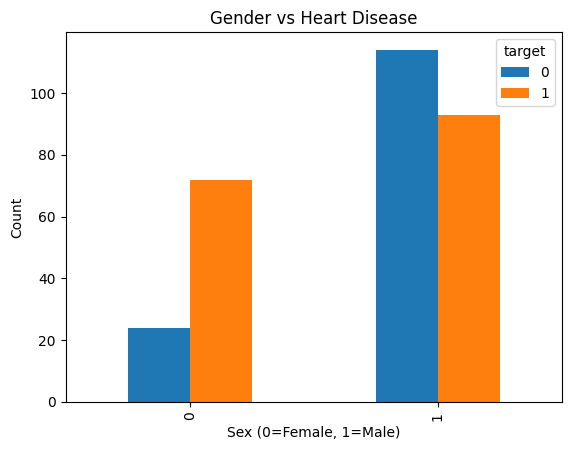

In [11]:
plt.hist(df['trestbps'], bins=10)
plt.title("Resting Blood Pressure Distribution")
plt.xlabel("BP")
plt.ylabel("Frequency")
plt.show()
pd.crosstab(df['sex'], df['target']).plot(kind='bar')
plt.title("Gender vs Heart Disease")
plt.xlabel("Sex (0=Female, 1=Male)")
plt.ylabel("Count")
plt.show()

5. TRAIN MODEL

In [5]:
history = model.fit(X_train, y_train, epochs=20, batch_size=16, validation_split=0.1)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.4608 - loss: 0.8233 - val_accuracy: 0.5200 - val_loss: 0.7457
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5668 - loss: 0.6900 - val_accuracy: 0.7200 - val_loss: 0.6295
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6912 - loss: 0.6086 - val_accuracy: 0.7200 - val_loss: 0.5618
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7558 - loss: 0.5530 - val_accuracy: 0.7600 - val_loss: 0.5186
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7788 - loss: 0.5124 - val_accuracy: 0.8000 - val_loss: 0.4871
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7926 - loss: 0.4789 - val_accuracy: 0.7600 - val_loss: 0.4580
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8157 - loss: 0.4496 - val_accuracy: 0.7600 - val_loss: 0.4383
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8341 - loss: 0.4258 - val_accuracy: 0.7600 - val_l

6. EVALUATE MODEL

In [6]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Accuracy: 0.8688524590163934
Confusion Matrix:
 [[26  3]
 [ 5 27]]


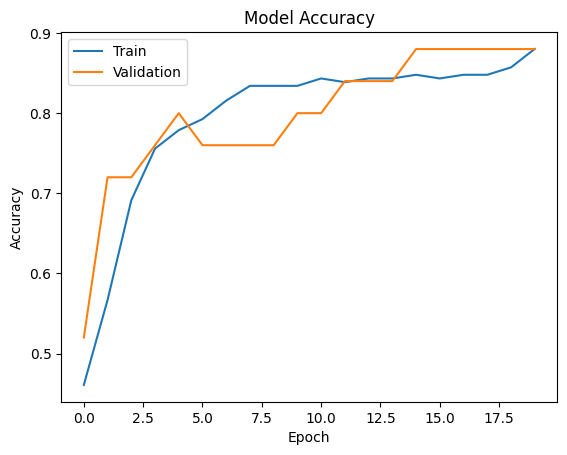

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()